# Simple Trading Simulation
Compare the models we have trained

In [1]:
import os
if not os.path.isfile('data.zip'):
    !wget https://raw.githubusercontent.com/zcakhaa/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/master/data/data.zip
    !unzip -n data.zip
    print('data downloaded.')
else:
    print('data already existed.')

data already existed.


In [2]:
# load packages
!pip install torchinfo
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

import torch
import torch.nn.functional as F
from torch.utils import data
from torchinfo import summary
import torch.nn as nn
import torch.optim as optim
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.33)
# N, D = X_train.shape

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [4]:
class LOBDataset(torch.utils.data.Dataset):
    """
    Memory-efficient FI-2010 dataset with
    imbalance-based microstructure features.
    """

    def __init__(
        self,
        data,
        k=4,
        num_classes=3,
        T=100,
    ):

        self.T = T
        self.k = k
        self.num_classes = num_classes

        # ======================================
        # Raw LOB Features
        # ======================================

        lob = data[:40].T.astype(np.float32)

        # Shape:
        # (timesteps, 40)

        # ======================================
        # Extract Volumes
        # ======================================

        ask_volumes = lob[:, 1::4]
        bid_volumes = lob[:, 3::4]

        # ======================================
        # Order Imbalance
        # ======================================

        total_bid_volume = np.sum(
            bid_volumes,
            axis=1
        )

        total_ask_volume = np.sum(
            ask_volumes,
            axis=1
        )

        imbalance = (
            (total_bid_volume - total_ask_volume)
            / (total_bid_volume + total_ask_volume + 1e-8)
        ).reshape(-1, 1)

        # ======================================
        # Queue Imbalance
        # ======================================

        queue_imbalance = (
            (bid_volumes[:, 0] - ask_volumes[:, 0])
            / (bid_volumes[:, 0] + ask_volumes[:, 0] + 1e-8)
        ).reshape(-1, 1)

        # ======================================
        # Final Features
        # ======================================

        engineered_features = np.concatenate(
            [
                imbalance,
                queue_imbalance,
            ],
            axis=1
        ).astype(np.float32)

        self.x = np.concatenate(
            [
                lob,
                engineered_features,
            ],
            axis=1
        ).astype(np.float32)

        # Final shape:
        # (timesteps, 42)

        # ======================================
        # Labels
        # ======================================

        self.y = (
            data[144 + k - 1]
            .astype(np.int64)
            - 1
        )

    def __len__(self):

        return len(self.x) - self.T

    def __getitem__(self, idx):

        # ======================================
        # Rolling Window
        # ======================================

        x_window = self.x[
            idx : idx + self.T
        ]

        # Shape:
        # (T, 42)

        y_label = self.y[
            idx + self.T - 1
        ]

        # ======================================
        # Tensor Conversion
        # ======================================

        x_tensor = torch.tensor(
            x_window,
            dtype=torch.float32
        ).unsqueeze(0)

        # Final shape:
        # (1, T, 42)

        y_tensor = torch.tensor(
            y_label,
            dtype=torch.long
        )

        return x_tensor, y_tensor

# Data preparation

We used no auction dataset that is normalised by decimal precision approach in their work. The first seven days are training data and the last three days are testing data. A validation set (20%) from the training set is used to monitor the overfitting behaviours.  

The first 40 columns of the FI-2010 dataset are 10 levels ask and bid information for a limit order book and we only use these 40 features in our network. The last 5 columns of the FI-2010 dataset are the labels with different prediction horizons.

In [5]:
import numpy as np
from pathlib import Path

# ======================================
# Memory-Efficient Loader
# ======================================

def load_dataset(file_path):
    """
    Load dataset using float32 instead of float64.

    This cuts memory usage roughly in half.
    """

    return np.loadtxt(
        file_path,
        dtype=np.float32
    )


# ======================================
# Load Test Sets
# ======================================

test_files = [
    "Test_Dst_NoAuction_DecPre_CF_7.txt",
    "Test_Dst_NoAuction_DecPre_CF_8.txt",
    "Test_Dst_NoAuction_DecPre_CF_9.txt",
]

test_arrays = []

for file_name in test_files:

    arr = load_dataset(
        file_name
    )

    test_arrays.append(arr)

# Concatenate across time dimension
dec_test = np.concatenate(
    test_arrays,
    axis=1
)

# Free temporary arrays
del test_arrays

batch_size = 64

dataset_test = LOBDataset(
    data=dec_test,
    k=4,
    num_classes=3,
    T=100,
)

test_loader = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=batch_size,
    shuffle=False,
)

print("Test:", dec_test.shape)

Test: (149, 139587)


# Model Architecture

Please find the detailed discussion of our model architecture in our paper.

In [6]:
class attentiondeeplob(nn.Module):

    def __init__(self, y_len):
        super().__init__()

        self.y_len = y_len

        # ======================================
        # Convolution Blocks
        # ======================================

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(1, 2), stride=(1, 2)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(1, 2), stride=(1, 2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(1, 10)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )

        # ======================================
        # Inception Modules
        # ======================================

        self.inp1 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=(1, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 64, kernel_size=(3, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )

        self.inp2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=(1, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 64, kernel_size=(5, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )

        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),

            nn.Conv2d(32, 64, kernel_size=(1, 1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )

        # ======================================
        # Transformer Encoder
        # ======================================

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=192,
            nhead=4,
            dim_feedforward=256,
            dropout=0.2,
            batch_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=1,
        )

        # ======================================
        # Output Layer
        # ======================================

        self.fc1 = nn.Linear(192, self.y_len)

    def forward(self, x):

        # ======================================
        # CNN Feature Extraction
        # ======================================

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        # ======================================
        # Inception
        # ======================================

        x_inp1 = self.inp1(x)
        x_inp2 = self.inp2(x)
        x_inp3 = self.inp3(x)

        x = torch.cat(
            (x_inp1, x_inp2, x_inp3),
            dim=1
        )

        # ======================================
        # Reshape for Transformer
        # ======================================

        x = x.permute(0, 2, 1, 3)

        x = torch.reshape(
            x,
            (-1, x.shape[1], x.shape[2])
        )

        # Shape:
        # (batch, seq_len, 192)

        # ======================================
        # Transformer Encoder
        # ======================================

        x = self.transformer(x)

        # ======================================
        # Final Timestep
        # ======================================

        x = x[:, -1, :]

        # ======================================
        # Output Layer
        # ======================================

        x = self.fc1(x)

        return x

class deeplob(nn.Module):
    def __init__(self, y_len):
        super().__init__()
        self.y_len = y_len

        # convolution blocks
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.LeakyReLU(negative_slope=0.01),
#             nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,10)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )

        # inception moduels
        self.inp1 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(5,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )

        # lstm layers
        self.lstm = nn.LSTM(input_size=192, hidden_size=64, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(64, self.y_len)

    def forward(self, x):
        # h0: (number of hidden layers, batch size, hidden size)
        h0 = torch.zeros(1, x.size(0), 64).to(device)
        c0 = torch.zeros(1, x.size(0), 64).to(device)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        x_inp1 = self.inp1(x)
        x_inp2 = self.inp2(x)
        x_inp3 = self.inp3(x)

        x = torch.cat((x_inp1, x_inp2, x_inp3), dim=1)

#         x = torch.transpose(x, 1, 2)
        x = x.permute(0, 2, 1, 3)
        x = torch.reshape(x, (-1, x.shape[1], x.shape[2]))

        x, _ = self.lstm(x, (h0, c0))
        x = x[:, -1, :]
        x = self.fc1(x)
        forecast_y = torch.softmax(x, dim=1)

        return forecast_y

# Simulation


========== Original DeepLOB ==========

Classification Metrics
Accuracy: 0.7562
Precision: 0.7385
Recall: 0.7394
F1 Score: 0.7385

Trading Metrics
Confidence Threshold: 0.5
Number of Trades: 10383
Win Rate: 0.3885
Average Trade PnL: -0.000019
Total PnL: -0.198002
Sharpe Ratio: -0.0039

Classification Report
              precision    recall  f1-score   support

           0     0.7184    0.6806    0.6990     38408
           1     0.8249    0.8213    0.8231     65995
           2     0.6721    0.7163    0.6935     35084

    accuracy                         0.7562    139487
   macro avg     0.7385    0.7394    0.7385    139487
weighted avg     0.7572    0.7562    0.7564    139487


========== Feature Engineered DeepLOB ==========

Classification Metrics
Accuracy: 0.7453
Precision: 0.7268
Recall: 0.7221
F1 Score: 0.7243

Trading Metrics
Confidence Threshold: 0.5
Number of Trades: 9945
Win Rate: 0.3918
Average Trade PnL: -0.000017
Total PnL: -0.171101
Sharpe Ratio: -0.0034

Classificati

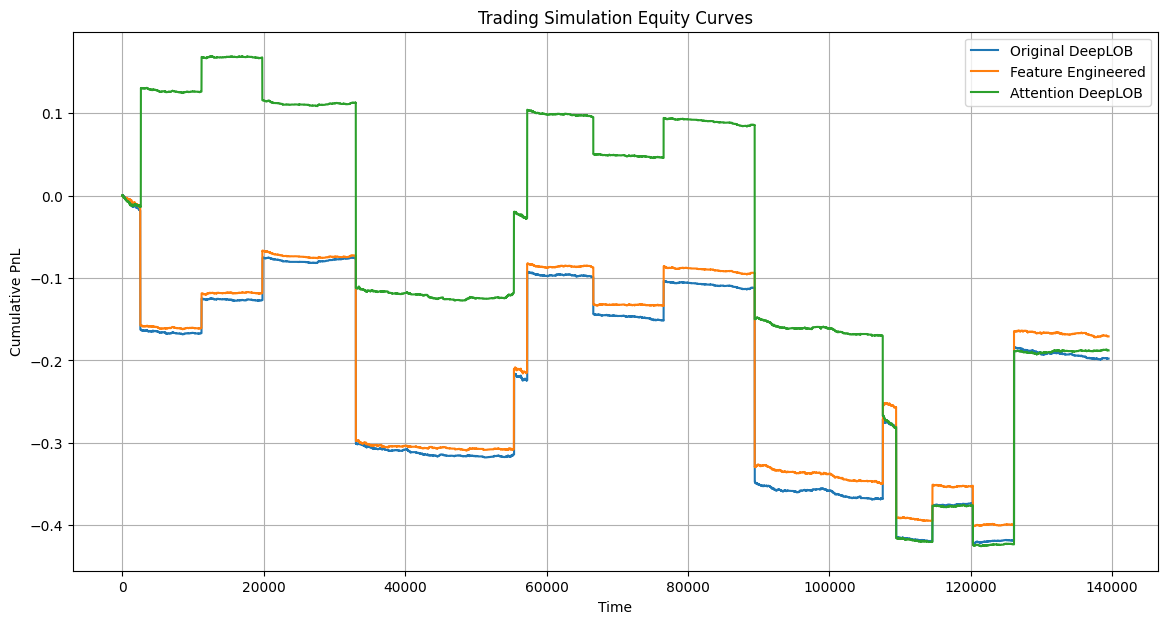

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


# ======================================
# Trading Simulation Assumptions
# ======================================

# 1. Predictions:
#    0 = Downward movement
#    1 = Stationary
#    2 = Upward movement
#
# 2. Trading Rules:
#    - Buy when model predicts upward movement
#    - Sell when model predicts downward movement
#    - Hold when prediction is stationary
#
# 3. Position Sizing:
#    - Fixed size of 1 share per trade
#
# 4. Execution:
#    - Executed immediately at mid-price
#
# 5. Costs:
#    - No transaction costs
#    - No slippage
#
# 6. Position Constraints:
#    - Long-only strategy
#    - Only 1 active position at a time
#
# 7. End-of-Day:
#    - All positions closed at final timestep


# ======================================
# Load Models
# ======================================

original_lob_model = deeplob(y_len=3)

original_lob_model.load_state_dict(
    torch.load(
        "best_val_model_pytorch.pt",
        map_location=device
    )
)

original_lob_model = original_lob_model.to(device)

original_lob_model.eval()


feature_engineered_lob_model = deeplob(y_len=3)

feature_engineered_lob_model.load_state_dict(
    torch.load(
        "best_val_featureengmodel_pytorch.pt",
        map_location=device
    )
)

feature_engineered_lob_model = (
    feature_engineered_lob_model.to(device)
)

feature_engineered_lob_model.eval()


attention_deep_lob_model = attentiondeeplob(y_len=3)

attention_deep_lob_model.load_state_dict(
    torch.load(
        "best_val_attentiondeeplob_pytorch.pt",
        map_location=device
    )
)

attention_deep_lob_model = (
    attention_deep_lob_model.to(device)
)

attention_deep_lob_model.eval()


# ======================================
# Mid-Price Extraction
# ======================================

ask_price_1 = dec_test[0]
bid_price_1 = dec_test[2]

mid_prices = (
    ask_price_1 + bid_price_1
) / 2

mid_prices = mid_prices[100:]


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

CONFIDENCE_THRESHOLD = 0.5


# ======================================
# Trading Simulation + Metrics
# ======================================

def run_trading_simulation(
    model,
    test_loader,
    mid_prices,
    model_name,
):

    predictions_all = []
    targets_all = []
    confidences_all = []

    # ======================================
    # Generate Predictions
    # ======================================

    with torch.no_grad():

        for inputs, targets in test_loader:

            inputs = inputs.to(
                device,
                non_blocking=True
            )

            outputs = model(inputs)

            probs = torch.softmax(
                outputs,
                dim=1
            )

            confidences, predictions = probs.max(dim=1)

            predictions_all.extend(
                predictions.cpu().numpy()
            )

            targets_all.extend(
                targets.cpu().numpy()
            )

            confidences_all.extend(
                confidences.cpu().numpy()
            )

    predictions_all = np.array(
        predictions_all
    )

    targets_all = np.array(
        targets_all
    )

    confidences_all = np.array(
        confidences_all
    )

    # ======================================
    # Classification Metrics
    # ======================================

    accuracy = accuracy_score(
        targets_all,
        predictions_all
    )

    precision = precision_score(
        targets_all,
        predictions_all,
        average="macro",
        zero_division=0,
    )

    recall = recall_score(
        targets_all,
        predictions_all,
        average="macro",
        zero_division=0,
    )

    f1 = f1_score(
        targets_all,
        predictions_all,
        average="macro",
        zero_division=0,
    )

    # ======================================
    # Trading State
    # ======================================

    position = 0

    entry_price = 0

    trade_returns = []

    equity_curve = []

    cumulative_pnl = 0

    # ======================================
    # Trading Loop
    # ======================================

    for t in range(len(predictions_all)):

        signal = predictions_all[t]

        confidence = confidences_all[t]

        current_price = mid_prices[t]

        # ==================================
        # Confidence Filter
        # ==================================

        if confidence < CONFIDENCE_THRESHOLD:

            equity_curve.append(
                cumulative_pnl
            )

            continue

        # ==================================
        # BUY SIGNAL
        # ==================================

        if signal == 2:

            # Close short
            if position == -1:

                pnl = (
                    entry_price
                    - current_price
                )

                cumulative_pnl += pnl

                trade_returns.append(pnl)

                position = 1

                entry_price = current_price

            # Open long
            elif position == 0:

                position = 1

                entry_price = current_price

        # ==================================
        # SELL SIGNAL
        # ==================================

        elif signal == 0:

            # Close long
            if position == 1:

                pnl = (
                    current_price
                    - entry_price
                )

                cumulative_pnl += pnl

                trade_returns.append(pnl)

                position = -1

                entry_price = current_price

            # Open short
            elif position == 0:

                position = -1

                entry_price = current_price

        equity_curve.append(
            cumulative_pnl
        )

    # ======================================
    # Close Final Position
    # ======================================

    final_price = mid_prices[-1]

    if position == 1:

        pnl = (
            final_price
            - entry_price
        )

        cumulative_pnl += pnl

        trade_returns.append(pnl)

    elif position == -1:

        pnl = (
            entry_price
            - final_price
        )

        cumulative_pnl += pnl

        trade_returns.append(pnl)

    # ======================================
    # Trading Metrics
    # ======================================

    trade_returns = np.array(
        trade_returns
    )

    total_pnl = np.sum(
        trade_returns
    )

    avg_trade = np.mean(
        trade_returns
    ) if len(trade_returns) > 0 else 0

    win_rate = np.mean(
        trade_returns > 0
    ) if len(trade_returns) > 0 else 0

    sharpe_ratio = (
        np.mean(trade_returns)
        / (np.std(trade_returns) + 1e-8)
    ) if len(trade_returns) > 0 else 0

    # ======================================
    # Print Results
    # ======================================

    print(f"\n========== {model_name} ==========")

    print("\nClassification Metrics")

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    print("\nTrading Metrics")

    print(f"Confidence Threshold: {CONFIDENCE_THRESHOLD}")

    print(f"Number of Trades: {len(trade_returns)}")

    print(f"Win Rate: {win_rate:.4f}")

    print(f"Average Trade PnL: {avg_trade:.6f}")

    print(f"Total PnL: {total_pnl:.6f}")

    print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

    print("\nClassification Report")

    print(
        classification_report(
            targets_all,
            predictions_all,
            digits=4,
            zero_division=0,
        )
    )

    return equity_curve


# ======================================
# Run Simulations
# ======================================

equity_original = run_trading_simulation(
    original_lob_model,
    test_loader,
    mid_prices,
    "Original DeepLOB"
)

equity_feature = run_trading_simulation(
    feature_engineered_lob_model,
    test_loader,
    mid_prices,
    "Feature Engineered DeepLOB"
)

equity_attention = run_trading_simulation(
    attention_deep_lob_model,
    test_loader,
    mid_prices,
    "Attention DeepLOB"
)


# ======================================
# Plot Equity Curves
# ======================================

plt.figure(figsize=(14, 7))

plt.plot(
    equity_original,
    label="Original DeepLOB"
)

plt.plot(
    equity_feature,
    label="Feature Engineered"
)

plt.plot(
    equity_attention,
    label="Attention DeepLOB"
)

plt.title(
    "Trading Simulation Equity Curves"
)

plt.xlabel("Time")

plt.ylabel("Cumulative PnL")

plt.legend()

plt.grid(True)

plt.show()